# HW6 - Self-Supervised and Contrastive Representation Learning (STL-10)

**Siva Surya Chandran** - sivasurya.chandran@sjsu.edu

ResNet-18 (no pretrained weights) is the backbone for every part:

| Part | What |
|:--|:--|
| A | Supervised, 10% of the labels (500 images), end to end |
| B | Rotation-prediction SSL on all 100,000 unlabeled images, then a linear probe on the same 500 labels |
| C | SimCLR-style contrastive learning on 20,000 unlabeled images, then a linear probe on the same 500 labels |
| D | Top-5 cosine nearest neighbours on the test set for all three encoders, same queries |

Run on an Apple-silicon Mac (MPS GPU). All augmentations are done on the GPU in batch.

## Step 0 - Personal parameters, seeds, environment

In [1]:
import os, time, json, random, hashlib, datetime
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchvision, matplotlib
import matplotlib.pyplot as plt

SID4 = 3215                     # see README: ID 019130215 -> 0215, leading zero replaced by 3
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")
print("(HW6 has no HP_ID mapping and no data slice; SEED, CLS_A and CLS_B are the ones used, CLS_A/CLS_B for the query images in Part D.)")

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__, "| torchvision", torchvision.__version__)
print("run started:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
os.makedirs("outputs", exist_ok=True); os.makedirs("checkpoints", exist_ok=True)
RESULTS = {"SID4": SID4, "SEED": SEED, "device": DEVICE}
T0 = time.time()
def stamp(msg): print(f"[{datetime.datetime.now().strftime('%H:%M:%S')} +{(time.time()-T0)/60:5.1f} min] {msg}", flush=True)

SID4=3215 SEED=3215 SLICE=215 HP_ID=5 CLS_A=5 CLS_B=2
(HW6 has no HP_ID mapping and no data slice; SEED, CLS_A and CLS_B are the ones used, CLS_A/CLS_B for the query images in Part D.)
device: mps | torch 2.14.1 | torchvision 0.29.1
run started: 2026-10-04 13:29:50


## Data

STL-10 (96x96 RGB, 10 classes): 5,000 labeled train, 8,000 test, 100,000 unlabeled. The 500-image labeled subset is
stratified (50 per class, 10% of train) and drawn with `SEED`. The same 500 images are used in Parts A, B and C.

In [2]:
def load(split):
    d = torchvision.datasets.STL10("data", split=split, download=True)
    x = torch.from_numpy(d.data)                       # uint8 N,3,96,96
    y = torch.from_numpy(d.labels).long() if hasattr(d, "labels") and d.labels is not None and len(d.labels) else None
    return x, y
xtr, ytr = load("train"); xte, yte = load("test"); xun, _ = load("unlabeled")
CLASSES = ["airplane","bird","car","cat","deer","dog","horse","monkey","ship","truck"]
print("train", tuple(xtr.shape), "test", tuple(xte.shape), "unlabeled", tuple(xun.shape))

# stratified 10% subset: 50 per class
rng = np.random.RandomState(SEED)
sub_idx = np.concatenate([rng.choice(np.where(ytr.numpy()==c)[0], 50, replace=False) for c in range(10)])
rng.shuffle(sub_idx)
x_lab, y_lab = xtr[sub_idx], ytr[sub_idx]
print("labeled subset:", tuple(x_lab.shape), "per-class counts:", torch.bincount(y_lab).tolist())
print("focus classes: CLS_A =", CLS_A, CLASSES[CLS_A], "| CLS_B =", CLS_B, CLASSES[CLS_B])

MEAN = torch.tensor([0.4467, 0.4398, 0.4066], device=DEVICE).view(1,3,1,1)
STD  = torch.tensor([0.2603, 0.2566, 0.2713], device=DEVICE).view(1,3,1,1)
def to_float(xb):                      # uint8 (cpu) -> float [0,1] on device
    return xb.to(DEVICE, non_blocking=True).float().div_(255)
def norm(x): return (x - MEAN) / STD

train (5000, 3, 96, 96) test (8000, 3, 96, 96) unlabeled (100000, 3, 96, 96)
labeled subset: (500, 3, 96, 96) per-class counts: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
focus classes: CLS_A = 5 dog | CLS_B = 2 car


## GPU augmentations

Implemented as batched tensor ops so training is not bottlenecked by CPU data loading. The four SimCLR augmentations
, taken from the course demo (`Demo_6_Self_Supervised_Learning.ipynb`): `RandomResizedCrop(scale=(0.6, 1.0))`, `RandomHorizontalFlip(0.5)`,
`ColorJitter(0.4, 0.4, 0.4, 0.1)`, `RandomGrayscale(0.2)`. The demo applies them with torchvision on 32x32 CIFAR images; here they are re-implemented as batched GPU ops on 96x96 images (jitter is applied to every
image as in torchvision's default, with the hue shift done as a rotation in YIQ space instead of HSV):

1. **Random resized crop** (scale 0.6-1.0, aspect 3/4-4/3, resized back to 96x96)
2. **Random horizontal flip** (p=0.5)
3. **Colour jitter** (brightness 0.4, contrast 0.4, saturation 0.4, hue 0.1)
4. **Random grayscale** (p=0.2)

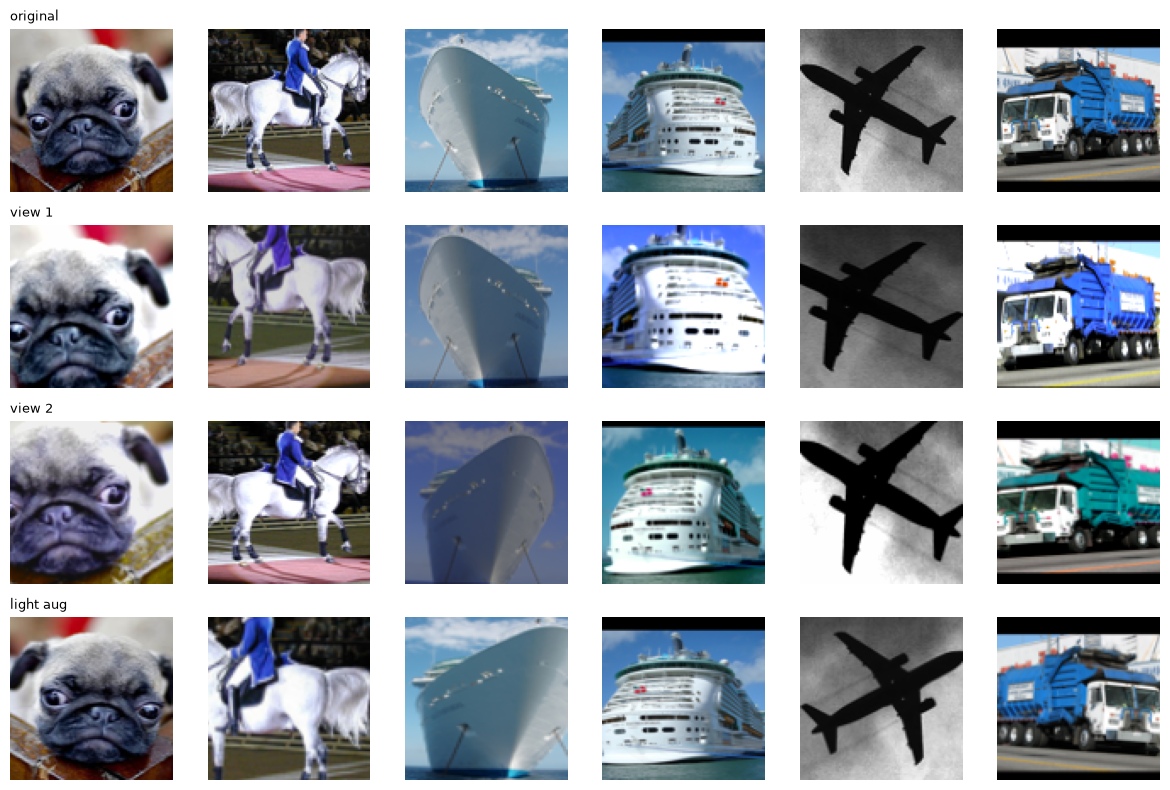

In [3]:
def rand_resized_crop_flip(x, scale=(0.2, 1.0), ratio=(3/4, 4/3), flip=True):
    """Per-sample random resized crop + horizontal flip, one affine grid_sample call."""
    B = x.shape[0]
    s = torch.empty(B, device=x.device).uniform_(*scale)
    r = torch.exp(torch.empty(B, device=x.device).uniform_(np.log(ratio[0]), np.log(ratio[1])))
    w = torch.sqrt(s * r).clamp(max=1.0); h = torch.sqrt(s / r).clamp(max=1.0)
    cx = (torch.rand(B, device=x.device) * 2 - 1) * (1 - w)
    cy = (torch.rand(B, device=x.device) * 2 - 1) * (1 - h)
    sign = torch.where(torch.rand(B, device=x.device) < 0.5, -1.0, 1.0) if flip else torch.ones(B, device=x.device)
    theta = torch.zeros(B, 2, 3, device=x.device)
    theta[:, 0, 0] = w * sign; theta[:, 0, 2] = cx; theta[:, 1, 1] = h; theta[:, 1, 2] = cy
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection", align_corners=False)

def gray(x): return (0.299*x[:,0:1] + 0.587*x[:,1:2] + 0.114*x[:,2:3])

_YIQ = torch.tensor([[0.299, 0.587, 0.114], [0.596, -0.274, -0.322], [0.211, -0.523, 0.312]], device=DEVICE)
def hue_shift(x, h):
    B = x.shape[0]; th = (torch.rand(B, device=x.device) * 2 - 1) * h * 2 * np.pi
    R = torch.zeros(B, 3, 3, device=x.device); R[:, 0, 0] = 1
    R[:, 1, 1] = torch.cos(th); R[:, 1, 2] = -torch.sin(th); R[:, 2, 1] = torch.sin(th); R[:, 2, 2] = torch.cos(th)
    M = torch.linalg.inv(_YIQ) @ R @ _YIQ                              # B,3,3
    return torch.einsum("bij,bjhw->bihw", M, x).clamp(0, 1)

def color_jitter(x, strength=0.4, hue=0.1):
    B = x.shape[0]; d = x.device
    u = lambda: (1 + (torch.rand(B,1,1,1,device=d)*2-1)*strength)
    y = (x * u()).clamp(0,1)                                           # brightness
    m = gray(y).mean(dim=(1,2,3), keepdim=True); y = ((y-m)*u()+m).clamp(0,1)   # contrast
    g = gray(y); y = ((y-g)*u()+g).clamp(0,1)                          # saturation
    return hue_shift(y, hue)                                           # hue

def random_gray(x, p=0.2):
    apply = (torch.rand(x.shape[0],1,1,1,device=x.device) < p)
    return torch.where(apply, gray(x).expand_as(x), x)

def simclr_aug(x):    # the 4 augmentations from the demo
    return random_gray(color_jitter(rand_resized_crop_flip(x, scale=(0.6, 1.0))))

def light_aug(x):     # used for supervised training (Part A) and the rotation pretext (Part B): crop + flip only
    return rand_resized_crop_flip(x, scale=(0.5, 1.0))

# sanity picture of the augmentations
_x = to_float(x_lab[:6])
fig, ax = plt.subplots(4, 6, figsize=(12, 8))
for r, (name, im) in enumerate([("original", _x), ("view 1", simclr_aug(_x)), ("view 2", simclr_aug(_x)), ("light aug", light_aug(_x))]):
    for c in range(6):
        ax[r, c].imshow(im[c].permute(1,2,0).cpu().clamp(0,1)); ax[r, c].axis("off")
    ax[r, 0].set_title(name, loc="left", fontsize=9)
plt.tight_layout(); plt.savefig("outputs/augmentations.png", dpi=110); plt.show()

## Shared helpers - encoder, evaluation, linear probe

In [4]:
def make_encoder():
    """ResNet-18, random init, fc removed -> 512-d features."""
    m = torchvision.models.resnet18(weights=None)
    m.fc = nn.Identity()
    return m.to(DEVICE)

@torch.no_grad()
def embed(encoder, x_u8, bs=500):
    encoder.eval()
    out = [encoder(norm(to_float(x_u8[i:i+bs]))).cpu() for i in range(0, len(x_u8), bs)]
    return torch.cat(out)

@torch.no_grad()
def accuracy_from_logits_fn(fn, x_u8, y, bs=500):
    preds = torch.cat([fn(norm(to_float(x_u8[i:i+bs]))).argmax(1).cpu() for i in range(0, len(x_u8), bs)])
    return (preds == y).float().mean().item(), preds

def param_hash(m):
    h = hashlib.md5()
    for p in m.state_dict().values(): h.update(p.detach().cpu().numpy().tobytes())
    return h.hexdigest()

def per_class_acc(preds, y): return [ (preds[y==c]==c).float().mean().item() for c in range(10) ]

def linear_probe(encoder, name, epochs=20, lr=1e-2, bs=32):
    """Encoder frozen (eval mode, no grad, params never given to the optimizer); only nn.Linear(512,10) trains."""
    set_seed()
    for p in encoder.parameters(): p.requires_grad_(False)
    encoder.eval()
    h_before = param_hash(encoder)
    ftr = embed(encoder, x_lab); fte = embed(encoder, xte)
    mu, sd = ftr.mean(0, keepdim=True), ftr.std(0, keepdim=True) + 1e-6      # feature standardisation, fit on the 500 labeled images only
    ftr_n, fte_n = ((ftr-mu)/sd).to(DEVICE), ((fte-mu)/sd).to(DEVICE)
    clf = nn.Linear(512, 10).to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    ytr_d = y_lab.to(DEVICE); n = len(ftr_n); hist = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=DEVICE); tot = 0
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            loss = F.cross_entropy(clf(ftr_n[idx]), ytr_d[idx])
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()*len(idx)
        with torch.no_grad(): te_acc = (clf(fte_n).argmax(1).cpu() == yte).float().mean().item()
        hist.append({"epoch": ep+1, "train_loss": tot/n, "test_acc": te_acc})
    assert param_hash(encoder) == h_before, "encoder changed during linear probe!"
    preds = clf(fte_n).argmax(1).cpu()
    acc = (preds == yte).float().mean().item()
    stamp(f"{name}: linear probe {epochs} ep, final train loss {hist[-1]['train_loss']:.3f}, TEST ACC {acc*100:.2f}%  (encoder hash unchanged: {h_before[:8]})")
    return acc, preds, hist

def save_curve(hist, key, title, path):
    plt.figure(figsize=(5,3.2)); plt.plot([h["epoch"] for h in hist], [h[key] for h in hist], marker="o", ms=3)
    plt.xlabel("epoch"); plt.ylabel(key); plt.title(title); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(path, dpi=110); plt.show()

## Part A - Supervised with 10% labels (500 images)

ResNet-18 from scratch + a 10-way linear head, trained end to end for 15 epochs on the 500-image subset (AdamW, lr 1e-3,
cosine decay, batch 64, crop + flip augmentation). Test accuracy is measured on all 8,000 test images.

[13:30:06 +  0.3 min] Part A epoch  1/15  train loss 2.252  test acc 20.54%


[13:30:10 +  0.3 min] Part A epoch  2/15  train loss 1.993  test acc 23.23%


[13:30:14 +  0.4 min] Part A epoch  3/15  train loss 1.874  test acc 28.10%


[13:30:18 +  0.5 min] Part A epoch  4/15  train loss 1.714  test acc 14.29%


[13:30:21 +  0.5 min] Part A epoch  5/15  train loss 1.585  test acc 26.71%


...

[13:30:48 +  1.0 min] Part A epoch 12/15  train loss 0.681  test acc 44.57%


[13:30:52 +  1.0 min] Part A epoch 13/15  train loss 0.653  test acc 44.59%


[13:30:56 +  1.1 min] Part A epoch 14/15  train loss 0.589  test acc 43.87%


[13:31:00 +  1.2 min] Part A epoch 15/15  train loss 0.527  test acc 43.95%


[13:31:04 +  1.2 min] PART A  supervised 10% labels  TEST ACC = 43.95%


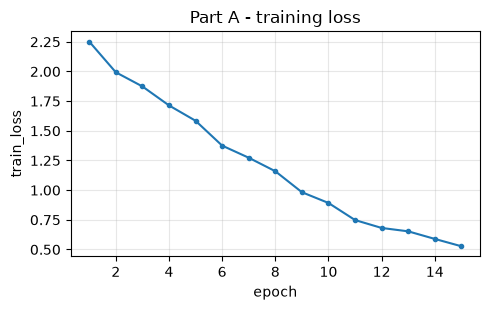

In [5]:
set_seed()
class Classifier(nn.Module):
    def __init__(self, enc): super().__init__(); self.enc = enc; self.head = nn.Linear(512, 10)
    def forward(self, x): return self.head(self.enc(x))

enc_sup = make_encoder(); model_a = Classifier(enc_sup).to(DEVICE)
EP_A, BS_A = 15, 64
opt = torch.optim.AdamW(model_a.parameters(), lr=1e-3, weight_decay=5e-4)
steps = EP_A * int(np.ceil(500/BS_A)); sched = torch.optim.lr_scheduler.OneCycleLR(opt, 1e-3, total_steps=steps, pct_start=0.15)
hist_a = []
for ep in range(EP_A):
    model_a.train(); perm = torch.randperm(500); tot = 0
    for i in range(0, 500, BS_A):
        idx = perm[i:i+BS_A]
        xb = norm(light_aug(to_float(x_lab[idx]))); yb = y_lab[idx].to(DEVICE)
        loss = F.cross_entropy(model_a(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); tot += loss.item()*len(idx)
    model_a.eval(); acc, _ = accuracy_from_logits_fn(model_a, xte, yte)
    hist_a.append({"epoch": ep+1, "train_loss": tot/500, "test_acc": acc})
    stamp(f"Part A epoch {ep+1:2d}/{EP_A}  train loss {tot/500:.3f}  test acc {acc*100:.2f}%")
acc_a, preds_a = accuracy_from_logits_fn(model_a, xte, yte)
RESULTS["A"] = {"test_acc": acc_a, "per_class": per_class_acc(preds_a, yte), "history": hist_a, "epochs": EP_A}
torch.save(enc_sup.state_dict(), "checkpoints/encoder_supervised.pt")
stamp(f"PART A  supervised 10% labels  TEST ACC = {acc_a*100:.2f}%")
save_curve(hist_a, "train_loss", "Part A - training loss", "outputs/partA_loss.png")

## Part B - Rotation self-supervised learning

Pretext task: every unlabeled image (all 100,000) is given a random rotation in {0, 90, 180, 270} each time it is drawn;
the network (ResNet-18 + 4-way rotation head) predicts which one. 15 epochs, AdamW lr 1e-3 with cosine decay, batch 256.
Then the rotation head is dropped, the encoder is frozen, and a linear classifier is trained on the same 500 labeled images
for 20 epochs.

[13:33:57 +  4.1 min] Part B pretext epoch  1/15  loss 1.0402  rotation acc 55.86%


[13:36:53 +  7.1 min] Part B pretext epoch  2/15  loss 0.8531  rotation acc 65.23%


[13:39:43 +  9.9 min] Part B pretext epoch  3/15  loss 0.7718  rotation acc 68.92%


[13:42:35 + 12.8 min] Part B pretext epoch  4/15  loss 0.7080  rotation acc 71.85%


[13:45:31 + 15.7 min] Part B pretext epoch  5/15  loss 0.6628  rotation acc 73.59%


...

[14:02:42 + 32.9 min] Part B pretext epoch 11/15  loss 0.4732  rotation acc 81.71%


[14:05:40 + 35.8 min] Part B pretext epoch 12/15  loss 0.4547  rotation acc 82.59%


[14:08:24 + 38.6 min] Part B pretext epoch 13/15  loss 0.4385  rotation acc 83.13%


[14:11:06 + 41.3 min] Part B pretext epoch 14/15  loss 0.4283  rotation acc 83.61%


[14:13:50 + 44.0 min] Part B pretext epoch 15/15  loss 0.4254  rotation acc 83.66%


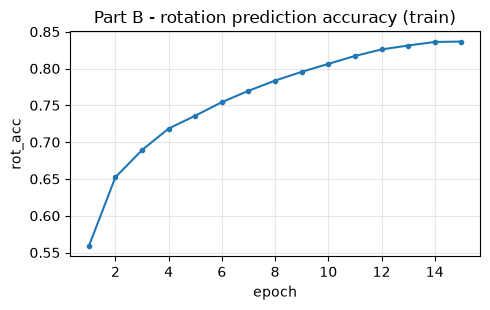

[14:13:55 + 44.1 min] Part B rotation accuracy on test images: 89.24%


[14:14:01 + 44.2 min] Part B rotation: linear probe 20 ep, final train loss 0.297, TEST ACC 47.85%  (encoder hash unchanged: a801cf62)


[14:14:01 + 44.2 min] PART B  rotation SSL + linear probe  TEST ACC = 47.85%


In [6]:
set_seed()
enc_rot = make_encoder(); rot_head = nn.Linear(512, 4).to(DEVICE)
EP_B, BS_B = 15, 256
params = list(enc_rot.parameters()) + list(rot_head.parameters())
opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
N_un = len(xun); steps_per_ep = N_un // BS_B
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EP_B*steps_per_ep)

def rotate_batch(x):
    k = torch.randint(0, 4, (x.shape[0],), device=x.device)
    out = x.clone()
    for r in range(1, 4):
        m = k == r
        if m.any(): out[m] = torch.rot90(x[m], r, dims=(2, 3))
    return out, k

hist_b = []
for ep in range(EP_B):
    enc_rot.train(); rot_head.train(); perm = torch.randperm(N_un); tot = cor = seen = 0
    for s in range(steps_per_ep):
        idx = perm[s*BS_B:(s+1)*BS_B]
        xb, kb = rotate_batch(light_aug(to_float(xun[idx])))
        logits = rot_head(enc_rot(norm(xb))); loss = F.cross_entropy(logits, kb)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        tot += loss.item()*len(idx); cor += (logits.argmax(1)==kb).sum().item(); seen += len(idx)
    hist_b.append({"epoch": ep+1, "train_loss": tot/seen, "rot_acc": cor/seen})
    stamp(f"Part B pretext epoch {ep+1:2d}/{EP_B}  loss {tot/seen:.4f}  rotation acc {cor/seen*100:.2f}%")
torch.save(enc_rot.state_dict(), "checkpoints/encoder_rotation.pt")
save_curve(hist_b, "rot_acc", "Part B - rotation prediction accuracy (train)", "outputs/partB_rot_acc.png")

# held-out rotation accuracy on the test images (sanity check that the pretext task was learned)
enc_rot.eval(); rot_head.eval(); set_seed(); c = n = 0
with torch.no_grad():
    for i in range(0, 8000, 500):
        xb, kb = rotate_batch(to_float(xte[i:i+500])); c += (rot_head(enc_rot(norm(xb))).argmax(1)==kb).sum().item(); n += len(kb)
RESULTS["B_pretext_test_rot_acc"] = c/n; stamp(f"Part B rotation accuracy on test images: {c/n*100:.2f}%")

# remove the rotation head, freeze the encoder, linear-probe on the 500 labels
del rot_head
acc_b, preds_b, hist_lin_b = linear_probe(enc_rot, "Part B rotation", epochs=20)
RESULTS["B"] = {"test_acc": acc_b, "per_class": per_class_acc(preds_b, yte), "pretext_history": hist_b, "linear_history": hist_lin_b, "pretext_epochs": EP_B, "linear_epochs": 20}
stamp(f"PART B  rotation SSL + linear probe  TEST ACC = {acc_b*100:.2f}%")

## Part C - SimCLR-style contrastive learning

20,000 unlabeled images (random subset, `SEED`). Each image gets two views from the 4 augmentations above. Encoder ->
projection head (512 -> 512 -> ReLU -> 128). NT-Xent loss with cosine similarity and **temperature 0.2**; the other
2(N-1) views in the batch are the negatives. Batch 256, 20 epochs, AdamW lr 1e-3 with cosine decay. Then the projection
head is dropped, the encoder frozen, and a linear classifier trained on the same 500 labeled images for 20 epochs.

[14:15:10 + 45.3 min] Part C pretext epoch  1/20  NT-Xent 4.2847  positive-pair top-1 25.4%


[14:16:21 + 46.5 min] Part C pretext epoch  2/20  NT-Xent 3.0806  positive-pair top-1 62.5%


[14:17:29 + 47.7 min] Part C pretext epoch  3/20  NT-Xent 2.7099  positive-pair top-1 80.6%


[14:18:35 + 48.8 min] Part C pretext epoch  4/20  NT-Xent 2.5331  positive-pair top-1 87.8%


[14:19:42 + 49.9 min] Part C pretext epoch  5/20  NT-Xent 2.4347  positive-pair top-1 91.1%


...

[14:31:35 + 61.8 min] Part C pretext epoch 16/20  NT-Xent 2.0571  positive-pair top-1 98.9%


[14:32:40 + 62.8 min] Part C pretext epoch 17/20  NT-Xent 2.0494  positive-pair top-1 98.9%


[14:33:44 + 63.9 min] Part C pretext epoch 18/20  NT-Xent 2.0365  positive-pair top-1 99.1%


[14:34:47 + 65.0 min] Part C pretext epoch 19/20  NT-Xent 2.0375  positive-pair top-1 99.0%


[14:35:51 + 66.0 min] Part C pretext epoch 20/20  NT-Xent 2.0318  positive-pair top-1 99.0%


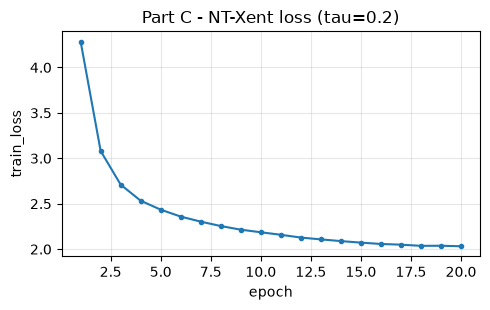

[14:35:57 + 66.1 min] Part C SimCLR: linear probe 20 ep, final train loss 0.388, TEST ACC 44.62%  (encoder hash unchanged: 90d5fec3)


[14:35:57 + 66.1 min] PART C  SimCLR + linear probe  TEST ACC = 44.62%


In [7]:
set_seed()
simclr_idx = torch.from_numpy(np.random.RandomState(SEED).choice(len(xun), 20000, replace=False))
x_simclr = xun[simclr_idx]
enc_cl = make_encoder()
proj = nn.Sequential(nn.Linear(512, 512), nn.ReLU(inplace=True), nn.Linear(512, 128)).to(DEVICE)
TAU, EP_C, BS_C = 0.2, 20, 256
opt = torch.optim.AdamW(list(enc_cl.parameters()) + list(proj.parameters()), lr=1e-3, weight_decay=1e-5)
steps_per_ep = len(x_simclr) // BS_C
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EP_C*steps_per_ep)

def nt_xent(z1, z2, tau=TAU):
    z = F.normalize(torch.cat([z1, z2]), dim=1)            # cosine similarity = dot product of unit vectors
    sim = z @ z.t() / tau
    n = z1.shape[0]
    sim.fill_diagonal_(float("-inf"))                      # a view is not its own negative
    target = torch.cat([torch.arange(n, 2*n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, target), (sim.argmax(1) == target).float().mean().item()

hist_c = []
for ep in range(EP_C):
    enc_cl.train(); proj.train(); perm = torch.randperm(len(x_simclr)); tot = top1 = 0
    for s in range(steps_per_ep):
        xb = to_float(x_simclr[perm[s*BS_C:(s+1)*BS_C]])
        v1, v2 = norm(simclr_aug(xb)), norm(simclr_aug(xb))
        z = proj(enc_cl(torch.cat([v1, v2])))                # one forward pass over both views
        loss, t1 = nt_xent(z[:len(xb)], z[len(xb):])
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); tot += loss.item(); top1 += t1
    hist_c.append({"epoch": ep+1, "train_loss": tot/steps_per_ep, "pos_top1": top1/steps_per_ep})
    stamp(f"Part C pretext epoch {ep+1:2d}/{EP_C}  NT-Xent {tot/steps_per_ep:.4f}  positive-pair top-1 {top1/steps_per_ep*100:.1f}%")
torch.save(enc_cl.state_dict(), "checkpoints/encoder_simclr.pt")
save_curve(hist_c, "train_loss", "Part C - NT-Xent loss (tau=0.2)", "outputs/partC_loss.png")

del proj   # remove projection head, freeze encoder, linear probe
acc_c, preds_c, hist_lin_c = linear_probe(enc_cl, "Part C SimCLR", epochs=20)
RESULTS["C"] = {"test_acc": acc_c, "per_class": per_class_acc(preds_c, yte), "pretext_history": hist_c, "linear_history": hist_lin_c, "pretext_epochs": EP_C, "linear_epochs": 20, "tau": TAU}
stamp(f"PART C  SimCLR + linear probe  TEST ACC = {acc_c*100:.2f}%")

## Reference point - random (untrained) encoder + the same linear probe

Not required by the assignment. It shows how much of the linear-probe accuracy comes from the architecture alone, which is
needed to judge how much the self-supervised pretraining actually adds.

[14:36:02 + 66.2 min] Random-init encoder: linear probe 20 ep, final train loss 0.152, TEST ACC 28.59%  (encoder hash unchanged: 9a4415e8)


Model                                      test acc
A  Supervised, 500 labels, end-to-end       43.95%
B  Rotation SSL + linear                    47.85%
C  SimCLR + linear                          44.62%
(ref) random encoder + linear               28.59%


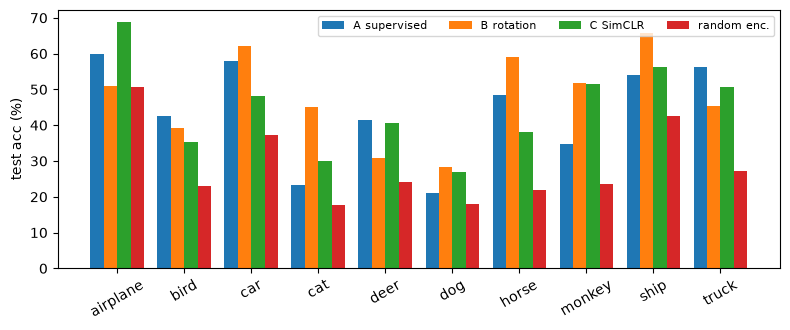

In [8]:
set_seed(); enc_rand = make_encoder()
acc_r, preds_r, _ = linear_probe(enc_rand, "Random-init encoder", epochs=20)
RESULTS["random_encoder"] = {"test_acc": acc_r, "per_class": per_class_acc(preds_r, yte)}

summary = [("A  Supervised, 500 labels, end-to-end", acc_a), ("B  Rotation SSL + linear", acc_b), ("C  SimCLR + linear", acc_c), ("(ref) random encoder + linear", acc_r)]
print(f"{'Model':42s} test acc"); [print(f"{n:42s} {a*100:6.2f}%") for n, a in summary]

fig, ax = plt.subplots(figsize=(8,3.4)); w = .2; xs = np.arange(10)
for i, (k, lab) in enumerate([("A","A supervised"),("B","B rotation"),("C","C SimCLR"),("random_encoder","random enc.")]):
    ax.bar(xs+(i-1.5)*w, np.array(RESULTS[k]["per_class"])*100, w, label=lab)
ax.set_xticks(xs); ax.set_xticklabels(CLASSES, rotation=30); ax.set_ylabel("test acc (%)"); ax.legend(ncol=4, fontsize=8); plt.tight_layout()
plt.savefig("outputs/per_class_accuracy.png", dpi=110); plt.show()

## Part D - Nearest-neighbour visualisation

512-d test-set embeddings from each encoder (the supervised encoder from Part A, the rotation encoder, the SimCLR encoder),
L2-normalised so a dot product is cosine similarity. For each query: top-5 neighbours among the other 7,999 test images
(the query itself is excluded). The queries are fixed once and shared by all three encoders: one image of `CLS_A` (dog), one of
`CLS_B` (car), and two more random classes. I also compute top-5 neighbour precision over **all** 8,000 test images, so the
conclusions don't rest on four hand-picked pictures.

[14:36:15 + 66.4 min] Supervised (A): precision@5 over all 8000 test queries = 39.66%, 1-NN accuracy = 42.40%


[14:36:15 + 66.4 min] Rotation SSL (B): precision@5 over all 8000 test queries = 40.97%, 1-NN accuracy = 44.74%


[14:36:15 + 66.4 min] SimCLR (C): precision@5 over all 8000 test queries = 39.89%, 1-NN accuracy = 43.22%


queries (test index, class): [(6224, 'dog'), (1842, 'car'), (3770, 'airplane'), (2209, 'deer')]
query 6224 (dog     ) Supervised (A)    -> ['monkey', 'deer', 'deer', 'cat', 'dog']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 6224 (dog     ) Rotation SSL (B)  -> ['horse', 'horse', 'dog', 'dog', 'horse']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 6224 (dog     ) SimCLR (C)        -> ['horse', 'horse', 'deer', 'dog', 'horse']  cos=[0.93, 0.93, 0.92, 0.9, 0.88]


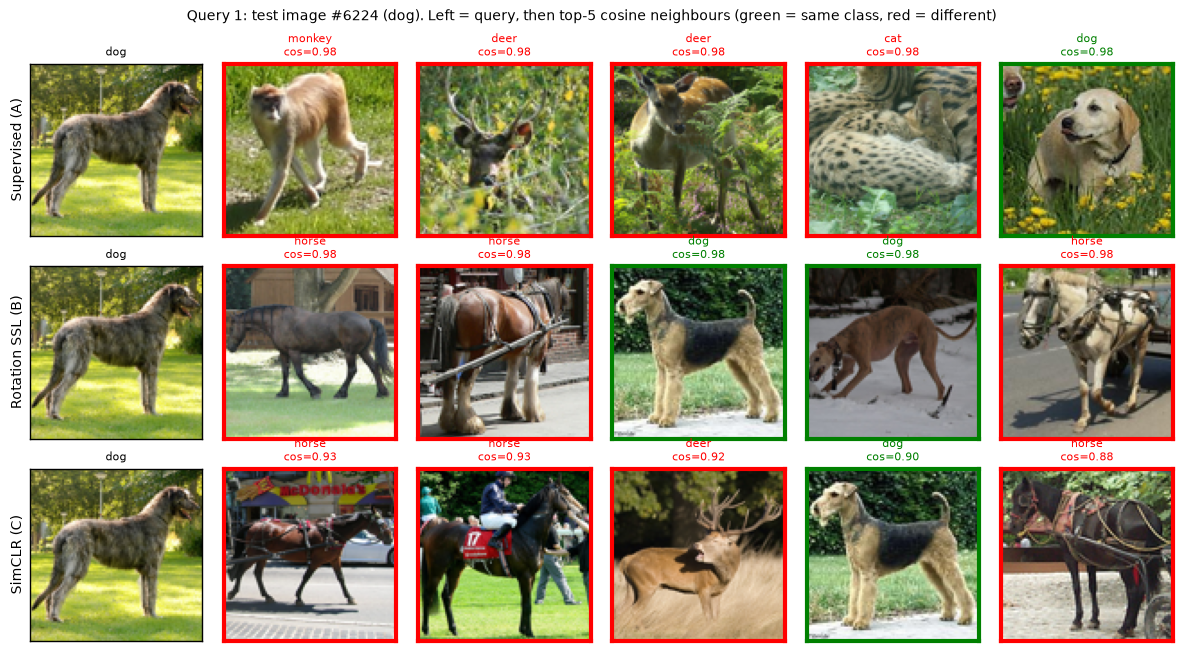

query 1842 (car     ) Supervised (A)    -> ['car', 'car', 'car', 'car', 'car']  cos=[0.98, 0.98, 0.98, 0.98, 0.98]
query 1842 (car     ) Rotation SSL (B)  -> ['car', 'truck', 'truck', 'truck', 'car']  cos=[0.99, 0.98, 0.98, 0.98, 0.98]
query 1842 (car     ) SimCLR (C)        -> ['car', 'car', 'car', 'car', 'car']  cos=[0.93, 0.93, 0.92, 0.92, 0.91]


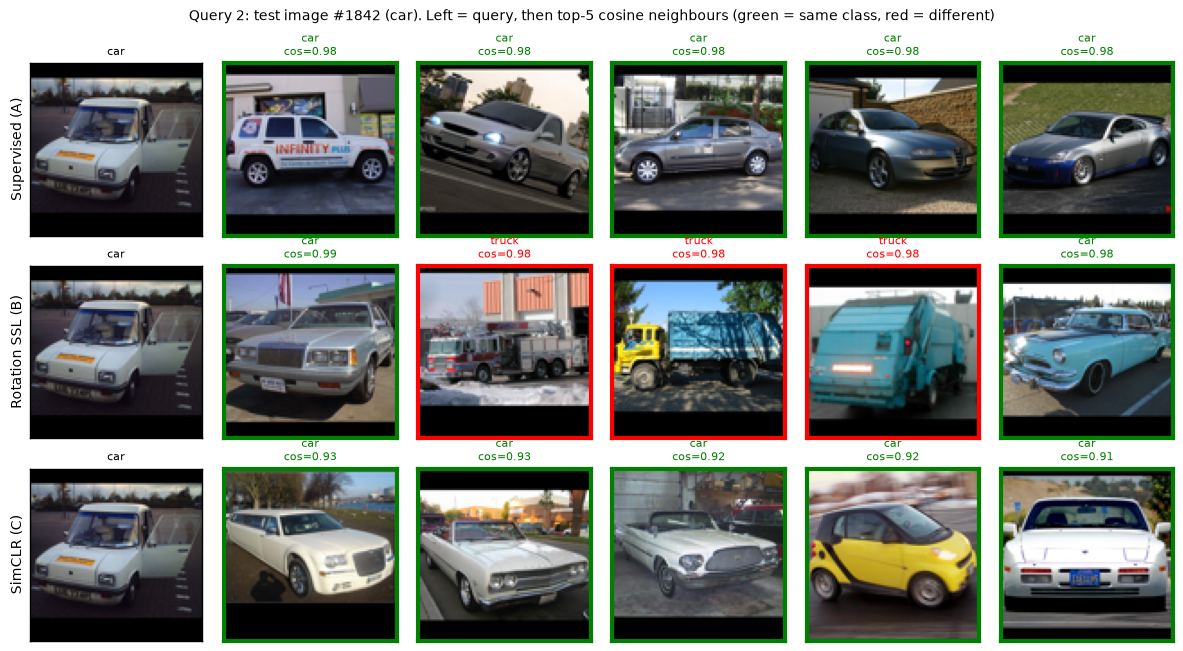

query 3770 (airplane) Supervised (A)    -> ['ship', 'airplane', 'airplane', 'airplane', 'ship']  cos=[0.95, 0.95, 0.95, 0.94, 0.94]
query 3770 (airplane) Rotation SSL (B)  -> ['airplane', 'airplane', 'ship', 'airplane', 'airplane']  cos=[0.98, 0.97, 0.97, 0.97, 0.97]
query 3770 (airplane) SimCLR (C)        -> ['truck', 'airplane', 'ship', 'airplane', 'horse']  cos=[0.88, 0.88, 0.88, 0.87, 0.87]


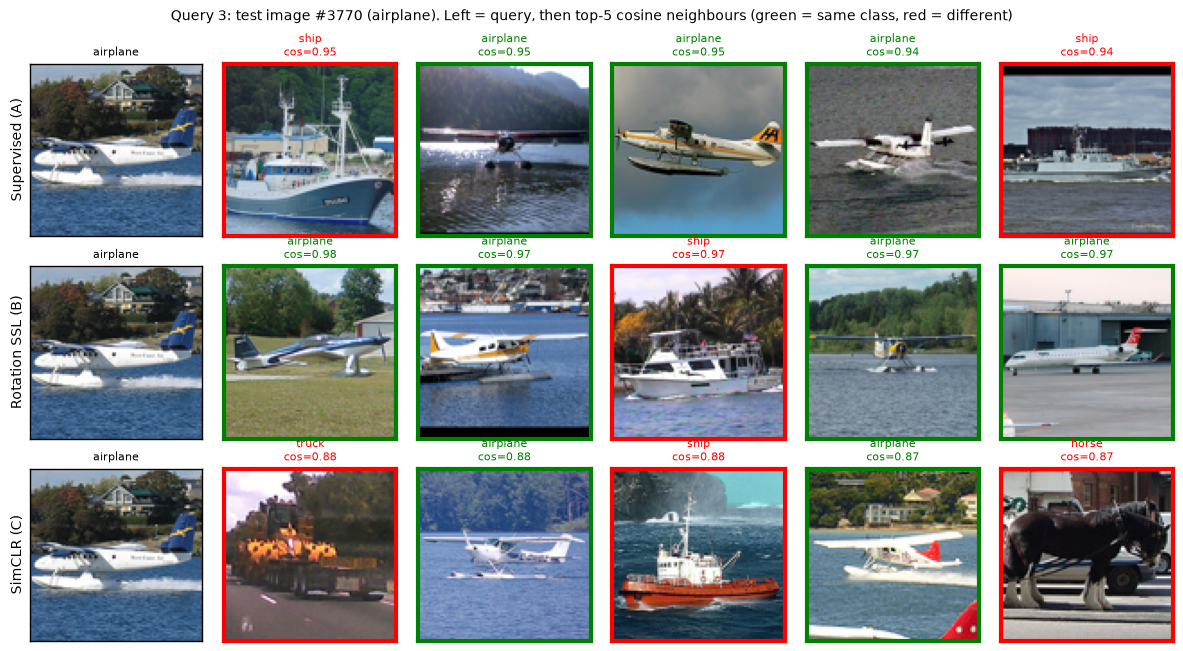

query 2209 (deer    ) Supervised (A)    -> ['deer', 'deer', 'monkey', 'deer', 'deer']  cos=[0.97, 0.96, 0.96, 0.96, 0.96]
query 2209 (deer    ) Rotation SSL (B)  -> ['deer', 'deer', 'horse', 'car', 'horse']  cos=[0.99, 0.99, 0.99, 0.99, 0.99]
query 2209 (deer    ) SimCLR (C)        -> ['deer', 'dog', 'deer', 'deer', 'deer']  cos=[0.94, 0.93, 0.92, 0.92, 0.91]


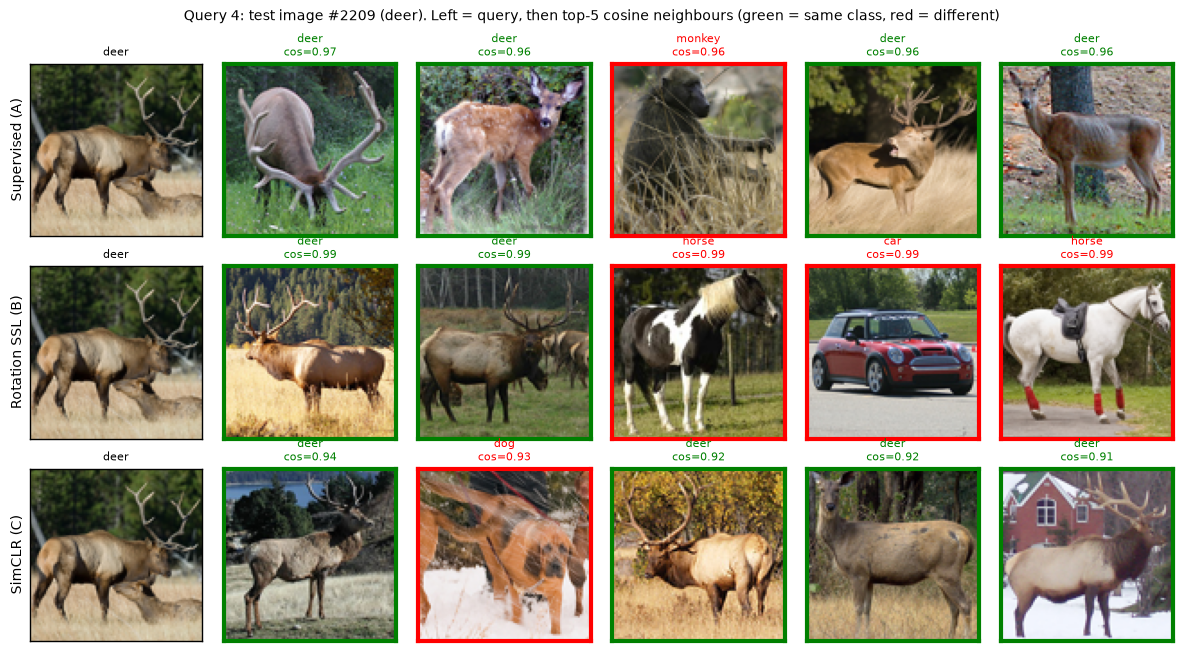

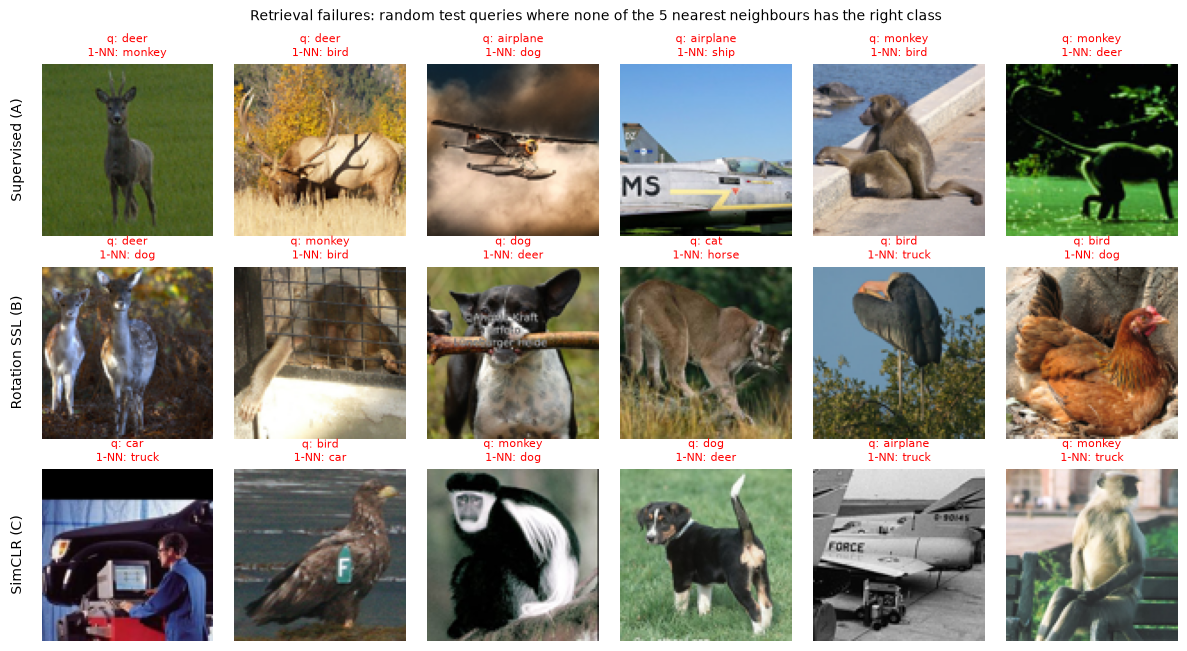

{'Supervised (A)': 1825, 'Rotation SSL (B)': 1591, 'SimCLR (C)': 1671} queries (of 8000) with 0/5 correct neighbours


In [9]:
emb = {"Supervised (A)": embed(enc_sup, xte), "Rotation SSL (B)": embed(enc_rot, xte), "SimCLR (C)": embed(enc_cl, xte)}
emb = {k: F.normalize(v, dim=1) for k, v in emb.items()}

def topk(e, q, k=5):
    sims = e @ e[q]; sims[q] = -2          # exclude the query itself
    v, i = sims.topk(k); return i.tolist(), v.tolist()

# full-test-set neighbour precision (top-5 neighbours share the query's class), 8000 queries
prec = {}
for name, e in emb.items():
    S = e @ e.t(); S.fill_diagonal_(-2); nn_idx = S.topk(5, dim=1).indices
    hit = (yte[nn_idx] == yte.unsqueeze(1)).float()
    prec[name] = {"precision@5": hit.mean().item(), "top1_nn_acc": hit[:,0].mean().item(),
                  "per_class_p@5": [hit[yte==c].mean().item() for c in range(10)]}
    stamp(f"{name}: precision@5 over all 8000 test queries = {prec[name]['precision@5']*100:.2f}%, 1-NN accuracy = {prec[name]['top1_nn_acc']*100:.2f}%")
RESULTS["knn"] = prec

# fixed queries: CLS_A, CLS_B, + two more classes, chosen with SEED
rq = np.random.RandomState(SEED)
others = [c for c in range(10) if c not in (CLS_A, CLS_B)]
q_classes = [CLS_A, CLS_B] + list(rq.choice(others, 2, replace=False))
queries = [int(rq.choice(np.where(yte.numpy()==c)[0])) for c in q_classes]
print("queries (test index, class):", [(q, CLASSES[yte[q]]) for q in queries])

def show(imgs_idx, ax_row, title_prefix, sims=None):
    for j, ti in enumerate(imgs_idx):
        a = ax_row[j]; a.imshow(xte[ti].permute(1,2,0).numpy()); a.set_xticks([]); a.set_yticks([])
        ok = (yte[ti] == yte[imgs_idx[0]]) if j > 0 else None
        col = "black" if j == 0 else ("green" if ok else "red")
        for sp in a.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(3 if j else 1)
        a.set_title(CLASSES[yte[ti]] + ("" if sims is None or j == 0 else f"\ncos={sims[j-1]:.2f}"), fontsize=8, color=col)

NN_RECORD = {}
for qi, q in enumerate(queries):
    fig, axes = plt.subplots(3, 6, figsize=(12, 6.6))
    for r, (name, e) in enumerate(emb.items()):
        idx, sims = topk(e, q)
        show([q] + idx, axes[r], name, sims)
        axes[r, 0].set_ylabel(name, fontsize=10)
        NN_RECORD[f"q{qi}_{q}_{name}"] = {"query_class": CLASSES[yte[q]], "neighbours": [CLASSES[yte[i]] for i in idx], "cos": [round(s,3) for s in sims], "idx": idx}
        print(f"query {q} ({CLASSES[yte[q]]:8s}) {name:17s} -> {[CLASSES[yte[i]] for i in idx]}  cos={[round(s,2) for s in sims]}")
    fig.suptitle(f"Query {qi+1}: test image #{q} ({CLASSES[yte[q]]}). Left = query, then top-5 cosine neighbours (green = same class, red = different)", fontsize=10)
    plt.tight_layout(); plt.savefig(f"outputs/nn_query{qi+1}_{CLASSES[yte[q]]}.png", dpi=110); plt.show()
RESULTS["nn_queries"] = NN_RECORD; RESULTS["queries"] = queries

# failure view: for each encoder, 6 test queries whose top-5 are worst (0/5 correct), shared pool of random "hard" queries
fig, axes = plt.subplots(3, 6, figsize=(12, 6.6))
S = {n: (e @ e.t()).fill_diagonal_(-2) for n, e in emb.items()}
for r, (name, e) in enumerate(emb.items()):
    nn_idx = S[name].topk(5, dim=1).indices; hit = (yte[nn_idx] == yte.unsqueeze(1)).float().sum(1)
    bad = torch.where(hit == 0)[0]; RESULTS["knn"][name]["n_queries_zero_correct"] = int(len(bad))
    pick = bad[torch.randperm(len(bad), generator=torch.Generator().manual_seed(SEED))[:6]].tolist()
    for c, qi in enumerate(pick):
        axes[r, c].imshow(xte[qi].permute(1,2,0).numpy()); axes[r, c].axis("off")
        axes[r, c].set_title(f"q: {CLASSES[yte[qi]]}\n1-NN: {CLASSES[yte[nn_idx[qi,0]]]}", fontsize=8, color="red")
    axes[r, 0].text(-0.1, 0.5, name, transform=axes[r,0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
fig.suptitle("Retrieval failures: random test queries where none of the 5 nearest neighbours has the right class", fontsize=10)
plt.tight_layout(); plt.savefig("outputs/nn_failures.png", dpi=110); plt.show()
print({n: v["n_queries_zero_correct"] for n, v in RESULTS["knn"].items()}, "queries (of 8000) with 0/5 correct neighbours")

In [10]:
# confusion for the three linear/supervised classifiers (what gets confused with what)
def top_confusions(preds, k=4):
    cm = torch.zeros(10, 10, dtype=torch.long)
    for t, p in zip(yte, preds): cm[t, p] += 1
    off = [(cm[i, j].item(), CLASSES[i], CLASSES[j]) for i in range(10) for j in range(10) if i != j]
    return sorted(off, reverse=True)[:k]
for n, p in [("A supervised", preds_a), ("B rotation", preds_b), ("C SimCLR", preds_c)]:
    print(n, "top confusions (count, true -> predicted):", top_confusions(p)); RESULTS[n.split()[0]]["top_confusions"] = top_confusions(p)

json.dump(RESULTS, open("outputs/results.json", "w"), indent=1)
stamp("all done; results saved to outputs/results.json")

A supervised top confusions (count, true -> predicted): [(261, 'car', 'truck'), (209, 'ship', 'truck'), (192, 'truck', 'car'), (155, 'dog', 'horse')]
B rotation top confusions (count, true -> predicted): [(172, 'truck', 'car'), (166, 'truck', 'ship'), (166, 'bird', 'monkey'), (163, 'deer', 'horse')]
C SimCLR top confusions (count, true -> predicted): [(221, 'car', 'truck'), (184, 'truck', 'car'), (172, 'dog', 'monkey'), (158, 'cat', 'monkey')]
[14:36:18 + 66.5 min] all done; results saved to outputs/results.json



## Results and analysis

Main results (single run, SEED = 3215, SimCLR with the **demo's augmentations**):

| Model | Training | Test acc (8,000 imgs) | Top-5 NN precision | 1-NN acc |
|:--|:--|--:|--:|--:|
| A - Supervised | 500 labels, end-to-end, 15 ep | 43.95% | 39.66% | 42.40% |
| B - Rotation SSL + linear | 100k unlabeled, 15 ep; linear on 500 labels | **47.85%** | **40.97%** | **44.74%** |
| C - SimCLR + linear | 20k unlabeled, tau=0.2, demo aug, 20 ep; linear on 500 labels | 44.62% | 39.89% | 43.22% |
| (ablation) C' - SimCLR, stronger crop (0.2-1) and no hue | same as C | 51.16% | 44.96% | 49.44% |
| (reference) random encoder + linear | none | 28.59% | - | - |

Extra experiments (`scripts/robustness.py`, 5 different 500-image subsets and seeds 3215-3219; the pretrained encoders are the same in every run, only the labeled subset, the supervised training and the probe change):

| Model | Mean +- std (%) | Min - max |
|:--|--:|--:|
| A - Supervised | 44.85 +- 1.13 | 43.81 - 46.25 |
| B - Rotation, 100k images | 47.06 +- 0.65 | 46.55 - 47.85 |
| B' - Rotation, 20k images (same images as SimCLR) | 42.81 +- 0.28 | 42.59 - 43.21 |
| C - SimCLR, demo augmentations | 44.34 +- 0.69 | 43.60 - 45.21 |
| C' - SimCLR, stronger crop / no hue (ablation) | 50.36 +- 1.29 | 48.60 - 51.71 |
| random encoder + linear | 29.42 +- 1.54 | 28.20 - 32.06 |

**Which model performed best.** With the augmentations the assignment prescribes (the demo's), **rotation SSL (B) is best: 47.85%** in the main run and 47.06 +- 0.65 over five subsets, about 2-3 points above both
supervised (44.85 +- 1.13) and SimCLR (44.34 +- 0.69). SimCLR and the supervised baseline are statistically indistinguishable (their ranges overlap). Both SSL encoders are far above a random
frozen encoder (29%), so the pretraining clearly learned something. The nearest-neighbour precision tells the same story (B 41.0% > C 39.9% > A 39.7%), though the gaps are small.

**The ranking depends on the SimCLR augmentations, and on how much unlabeled data each method sees.** Two controls I added change how the headline should be read:
- *Data-matched:* B used 100k unlabeled images, C only 20k. When rotation gets the same 20k images (B'), it drops to 42.8 +- 0.3, *below* SimCLR with the demo augmentations (44.3 +- 0.7). So rotation's lead over demo-SimCLR comes from seeing 5x more data, not from a better objective.
- *Augmentation strength:* my first SimCLR run used a stronger crop (scale 0.2-1.0) and no hue jitter. That variant reaches **51.16%** (50.36 +- 1.29 over five subsets) and beats everything, including rotation with 5x more data, by about 3 points.
  The demo uses crop scale 0.6-1.0 and adds hue; the two settings differ in both, so I cannot say which one matters, only that the combination does. Both are one pretraining run each.

**Why SimCLR with the demo augmentations underperformed.** Its positive-pair top-1 accuracy reached 99% by epoch 20 (97% by epoch 10) and the NT-Xent loss fell to 2.03, versus 81.5% and 2.68 with the stronger augmentation. The contrastive
task had become too easy: two crops that each cover 60-100% of the image overlap heavily, so the network can match them from low-level cues (colour layout, texture, the shared pixels) without learning anything object-level, and it
stops improving. That is my explanation, supported by the ablation but not isolated by it. The demo's settings were designed for 32x32 CIFAR images; on 96x96 STL-10 images with the same crop scale, the two views share more content.
*Why rotation did well:* the pretext task was learned strongly (89.2% rotation accuracy on test images). Rotation cannot be solved from colour or position alone, and it needs a sense of what is upright (ships 66%, horses 59%, monkeys 52%,
versus 43%, 22%, 24% for the random encoder). *Why supervised was weakest:* 500 images for an 11M-parameter ResNet-18 from scratch overfit (train loss 0.53, test accuracy about 44%, very unstable early: 14% at epoch 4, 38% at epoch 6). It is weakest on
cat (23%) and dog (21%), the classes that need more than 50 examples each, and its errors are mostly look-alike classes (car/truck 261, ship/truck 209).

**What could improve each model.**
- *Supervised (A):* stronger augmentation (RandAugment, mixup/cutmix), label smoothing, more weight decay, early stopping on a slice of the 500; or initialise from the B/C' encoder and fine-tune, the standard way to use few labels.
- *Rotation (B):* the pretext accuracy was still rising slowly at epoch 15 (83.7%), so train longer; combine with a second pretext task (jigsaw, colorization); and probe mid-network layers, where rotation features are usually strongest.
- *SimCLR (C):* make the task harder: crop scale (0.2, 1.0) as in C' (+6.5 points), stronger colour jitter, more negatives (batch 256 gives only 510; use a larger batch or a memory queue), 100+ epochs and all 100k unlabeled images (we used 20k).
- *Linear probes:* only 500 labels; the probe hyperparameters were fixed in advance and not tuned, and more labels or tuning would help all of them.

**What the nearest-neighbour visualisations showed** (`outputs/nn_query*.png`, `outputs/nn_failures.png`; green frame = same class, number of correct neighbours out of 5):

| Query | Supervised | Rotation | SimCLR |
|:--|--:|--:|--:|
| dog (CLS_A) | 1 | 2 | 1 |
| car (CLS_B) | 5 | 2 | 5 |
| airplane | 3 | 4 | 2 |
| deer | 4 | 2 | 4 |

- No encoder wins everywhere: SimCLR and supervised retrieve 5/5 cars while rotation mixes in trucks (its main confusion, truck/car 172); rotation is best on the airplane (4/5). Four queries cannot rank the models, which is why I also measured precision@5 over all 8,000 test images. There the three are close (39.7 / 41.0 / 39.9%), with rotation slightly ahead and the strong-crop SimCLR clearly ahead (45.0%).
- The mistakes are informative. For the floatplane query the wrong neighbours are boats on water (and for SimCLR a truck and a horse): the encoders match *scene and background* (water, grass, tarmac) as much as the object. Dog queries return horses, deer and monkeys: four-legged animals on grass. So the embeddings capture
  coarse semantics (animal vs vehicle) well but confuse look-alike classes within a group.
- The retrieval-failure gallery (all 5 neighbours wrong) shows unusual poses, cluttered or distracting backgrounds, and objects filling the frame (a monkey on a bench whose nearest neighbour is a truck, a parked jet in a black-and-white photo). Counts of queries with 0/5 correct neighbours: supervised 1,825, SimCLR 1,671, rotation 1,591 (of 8,000), strong-crop SimCLR 1,516.
- Cosine similarities are very high for supervised and rotation (0.94-0.99) and noticeably lower and more spread for SimCLR (0.87-0.94), consistent with its loss pushing different images apart. The absolute values are not comparable across encoders; only the ranking within an encoder is meaningful.

**Overall.** Unlabeled data helped: rotation SSL beat the 500-label supervised model by about 2-3 points, and SimCLR with a stronger crop beat it by about 5.5 points, both with the encoder frozen. The demo's SimCLR augmentations
were too weak for this dataset and only matched supervised. The conclusions are limited by one pretraining run per method (the five-subset study varies the labeled subset, not the pretraining seed), a short training schedule, and an untuned linear probe.
